# 🛍️ Exploration du Dataset Retail Customers

**Objectif :** Analyser un dataset de clients retail (4 372 clients, 52 variables) pour comprendre les comportements d'achat, les profils clients, et les facteurs liés au churn.

---
## Plan d'analyse
1. Chargement & aperçu général
2. Qualité des données (valeurs manquantes, doublons)
3. Analyse univariée — variables numériques
4. Analyse univariée — variables catégorielles
5. Analyse bivariée — relation avec le Churn
6. Corrélations entre variables numériques
7. Segmentation RFM & Profils clients
8. Synthèse & pistes de modélisation

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# Style global
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & Aperçu Général

In [3]:
# Charger le fichier (adapter le chemin si nécessaire)
PATH = '../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv'
df = pd.read_csv(PATH)

print(f'📐 Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'💾 Mémoire    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

📐 Dimensions : 4,372 lignes × 52 colonnes
💾 Mémoire    : 6.4 MB


In [4]:
# Aperçu des 5 premières lignes
df.head()

,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.95,13.60,-30.60,107.25,1693,5.43,-12,12,71,374,3,9,12,0.00,0.22,24,25,0.69,1,15,0,15,0.05,312,35,8.91,NaN,17/07/10,Yes,59.252.219.201,1.00,4.00,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.71,11.68,-15.00,68.00,1355,6.91,-3,32,342,374,2,13,10,0.17,1.72,106,106,5.89,1,24,0,24,0.12,196,18,10.89,NaN,2010-10-04,Yes,77.255.247.14,3.00,4.00,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.63,23.15,-60.84,132.80,5009,19.96,-36,360,370,374,4,12,11,0.06,1.46,115,117,6.39,1,4,0,4,0.02,251,18,13.94,46.00,12/09/2009,Yes,51.139.78.80,2.00,5.00,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.87,42.95,9.36,204.00,439,15.68,1,80,278,374,0,9,9,0.00,10.26,24,24,4.80,1,0,0,0,0.00,28,5,5.60,32.00,28/01/10,Yes,10.212.80.124,2.00,2.00,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.85,215.99,-131.40,350.40,58,9.67,-12,32,43,374,2,9,12,0.00,8.20,1,1,0.17,1,3,0,3,0.50,6,6,1.00,NaN,2009-12-10,Yes,186.34.121.80,2.00,1.00,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [5]:
# Types de données et colonnes
# On sépare manuellement les colonnes numériques et catégorielles
# (pandas 2+ remplace 'object' par 'str' pour les chaînes)
NUM_COLS = df.select_dtypes(include='number').columns.tolist()
CAT_COLS = [c for c in df.columns if df[c].dtype in ['object', 'str'] or str(df[c].dtype) == 'string']

print(f'🔢 Variables numériques  ({len(NUM_COLS)}) : {NUM_COLS}')
print()
print(f'🏷️  Variables catégorielles ({len(CAT_COLS)}) : {CAT_COLS}')

🔢 Variables numériques  (34) : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']

🏷️  Variables catégorielles (18) : ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountSt

## 2. Qualité des Données

**Points clés à vérifier :**
- Valeurs manquantes (NaN)
- Doublons
- Colonnes inutiles pour l'analyse (ex: IP, date brute)

=== Valeurs manquantes ===


,Count,Pct (%)
Age,1311,30.00
AvgDaysBetweenPurchases,79,1.80


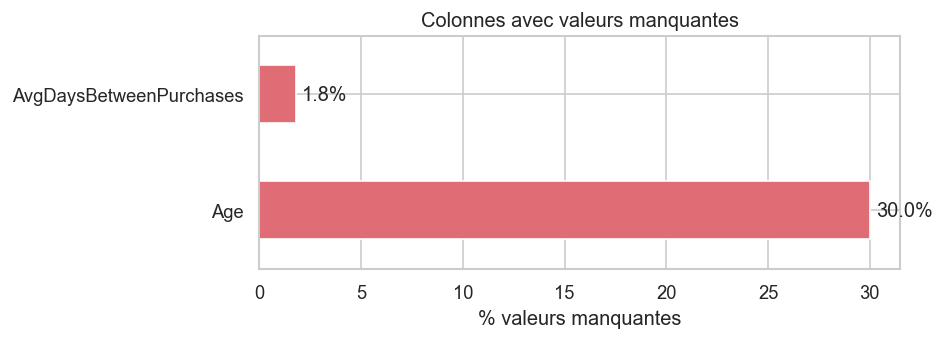

In [6]:
# Tableau des valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

miss_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
print('=== Valeurs manquantes ===')
display(miss_df)

# Visualisation
if not miss_df.empty:
    fig, ax = plt.subplots(figsize=(8, 3))
    miss_df['Pct (%)'].plot(kind='barh', ax=ax, color='#e06c75')
    ax.set_xlabel('% valeurs manquantes')
    ax.set_title('Colonnes avec valeurs manquantes')
    for i, v in enumerate(miss_df['Pct (%)']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
    plt.tight_layout()
    plt.show()

# Commentaire : Age a 30% de manquants (catégorie 'Inconnu' créée),
# AvgDaysBetweenPurchases a ~1.8% (clients avec 1 seul achat → imputation ou exclusion possible)

In [7]:
# Doublons
n_dup = df.duplicated().sum()
n_dup_id = df.duplicated(subset='CustomerID').sum()
print(f'Lignes dupliquées (entières)    : {n_dup}')
print(f'CustomerID dupliqués            : {n_dup_id}')
print()
# Colonnes à faible valeur analytique
print('⚠️  Colonnes à faible valeur analytique :')
print('  - LastLoginIP       → identifiant technique, pas de signal métier')
print('  - RegistrationDate  → à convertir en datetime si on veut la tenure')
print('  - NewsletterSubscribed → une seule modalité (Yes), aucune variance')

Lignes dupliquées (entières)    : 0
CustomerID dupliqués            : 0

⚠️  Colonnes à faible valeur analytique :
  - LastLoginIP       → identifiant technique, pas de signal métier
  - RegistrationDate  → à convertir en datetime si on veut la tenure
  - NewsletterSubscribed → une seule modalité (Yes), aucune variance


## 3. Analyse Univariée — Variables Numériques

On s'intéresse aux **variables RFM** (Recency, Frequency, Monetary) qui sont au cœur du comportement client,
ainsi qu'aux variables comportementales (ReturnRatio, WeekendPurchaseRatio, etc.).

In [8]:
# Statistiques descriptives des variables numériques clés
key_num = ['Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
           'CustomerTenureDays', 'ReturnRatio', 'WeekendPurchaseRatio',
           'UniqueProducts', 'CancelledTransactions', 'SatisfactionScore', 'Age']
display(df[key_num].describe().T)

,count,mean,std,min,25%,50%,75%,max
Recency,4372.00,92.05,100.77,1.00,17.00,50.00,143.00,374.00
Frequency,4372.00,5.08,9.34,1.00,1.00,3.00,5.00,248.00
MonetaryTotal,4372.00,1898.46,8219.35,-4287.63,293.36,648.08,1611.72,279489.02
MonetaryAvg,4372.00,28.84,127.32,-4287.63,10.99,16.92,23.54,3861.00
CustomerTenureDays,4372.00,133.39,132.85,0.00,0.00,97.50,255.25,373.00
ReturnRatio,4372.00,0.03,0.11,0.00,0.00,0.00,0.02,1.00
WeekendPurchaseRatio,4372.00,0.13,0.28,0.00,0.00,0.00,0.08,1.00
UniqueProducts,4372.00,61.21,85.43,1.00,15.00,35.00,77.00,1794.00
CancelledTransactions,4372.00,2.04,7.34,0.00,0.00,0.00,1.00,226.00
SatisfactionScore,4372.00,5.33,15.41,-1.00,2.00,3.00,4.00,99.00


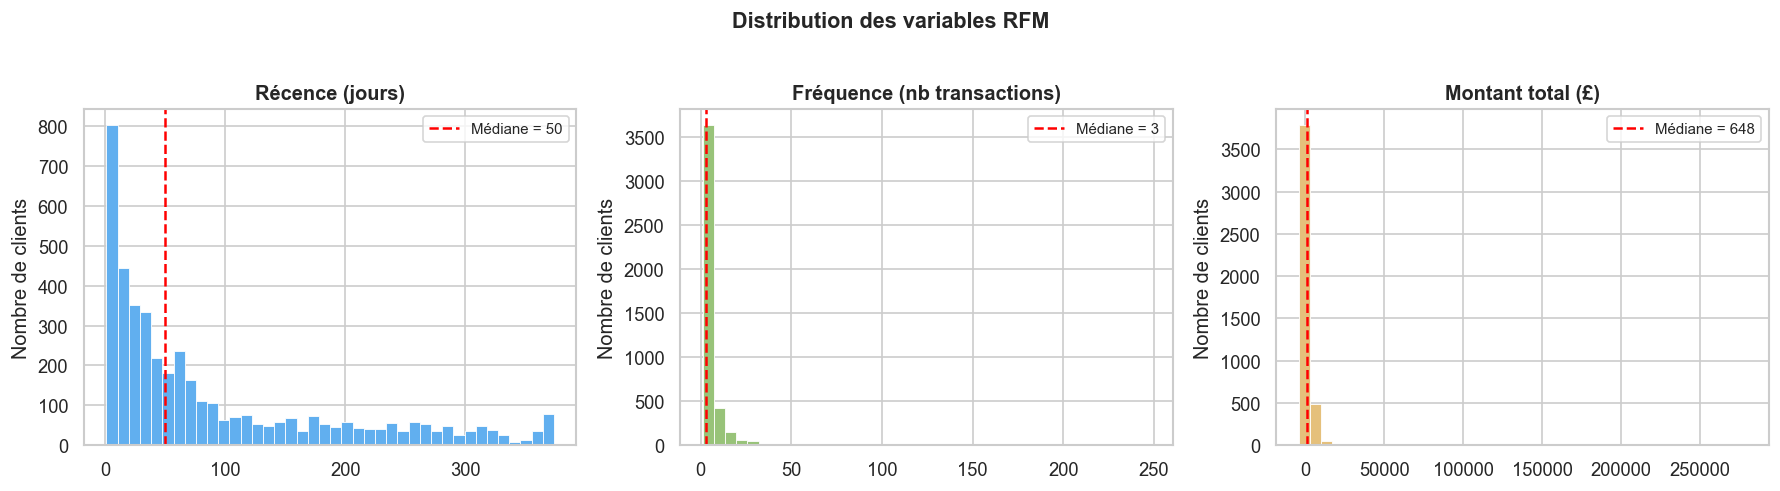

In [9]:
# Distributions des variables RFM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color, label in zip(
    axes,
    ['Recency', 'Frequency', 'MonetaryTotal'],
    ['#61afef', '#98c379', '#e5c07b'],
    ['Récence (jours)', 'Fréquence (nb transactions)', 'Montant total (£)']
):
    ax.hist(df[col].dropna(), bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1.5, label=f'Médiane = {df[col].median():.0f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel('Nombre de clients')

plt.suptitle('Distribution des variables RFM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# → Recency : distribution étalée, beaucoup de clients inactifs (>100 jours)
# → Frequency : concentrée sur les faibles valeurs, longue queue à droite (hyperactifs)
# → MonetaryTotal : très asymétrique, quelques clients à très haut panier

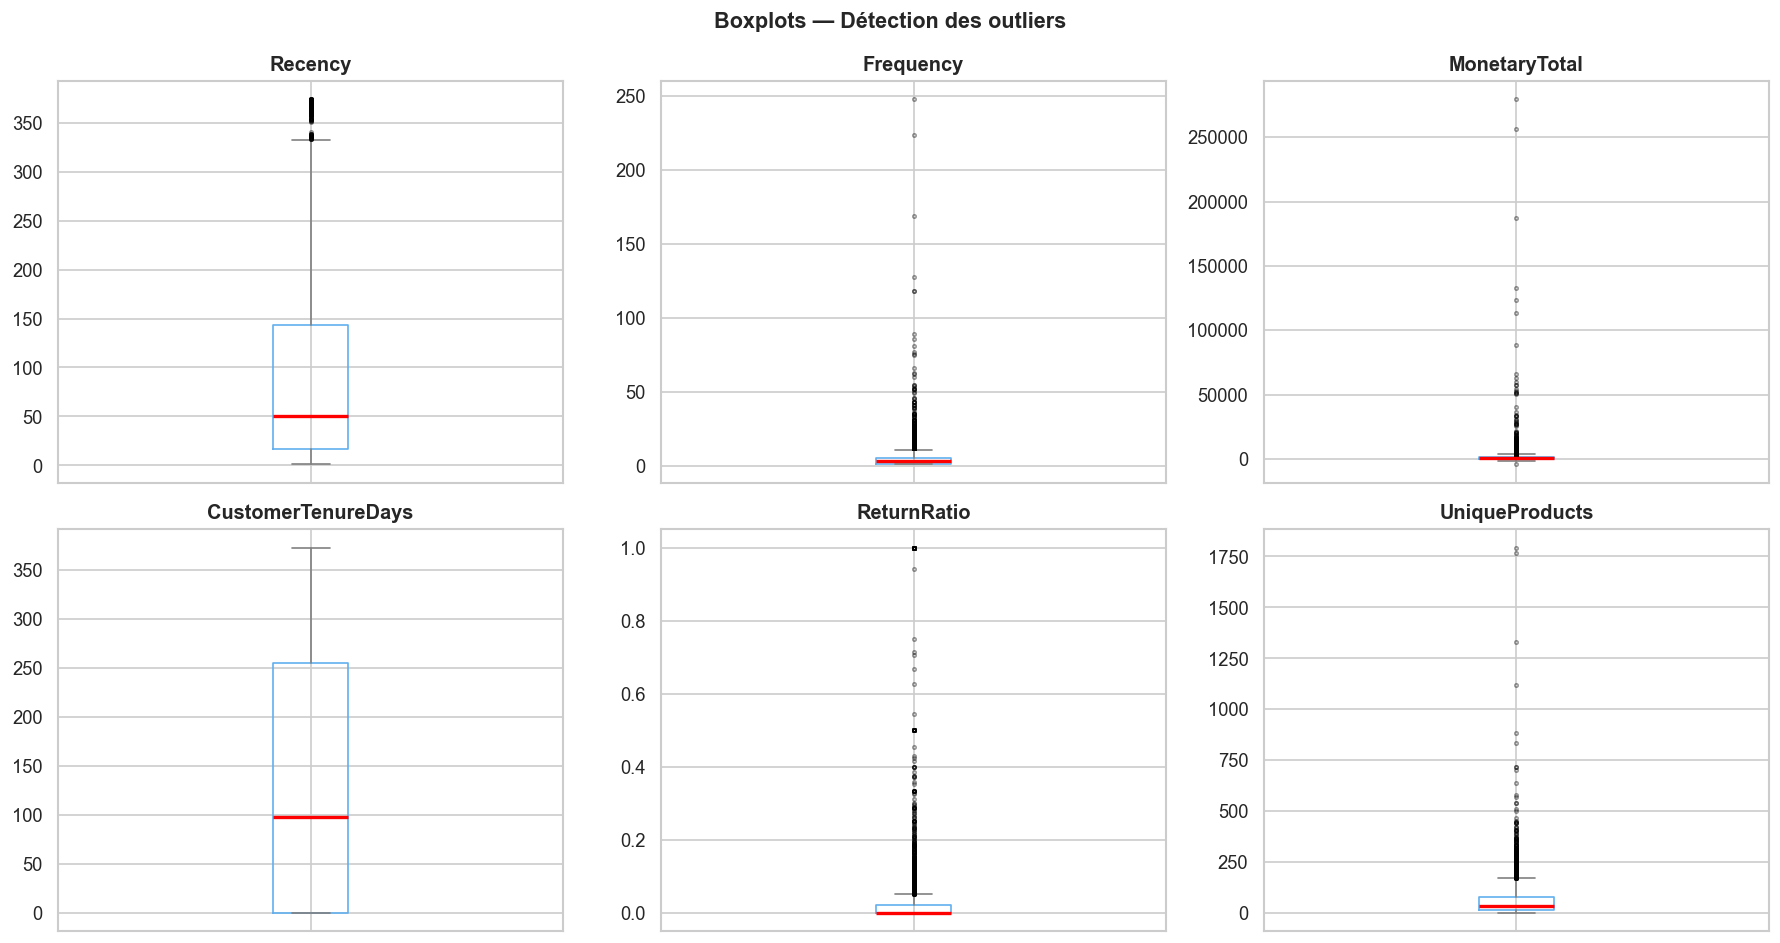

In [10]:
# Boxplots pour détecter les outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cols_box = ['Recency', 'Frequency', 'MonetaryTotal',
            'CustomerTenureDays', 'ReturnRatio', 'UniqueProducts']

for ax, col in zip(axes, cols_box):
    df.boxplot(column=col, ax=ax, boxprops=dict(color='#61afef'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', markersize=2, alpha=0.4, color='#e06c75'))
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels([])

plt.suptitle('Boxplots — Détection des outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Analyse Univariée — Variables Catégorielles

On examine la répartition des segments clients, profils démographiques et comportementaux.

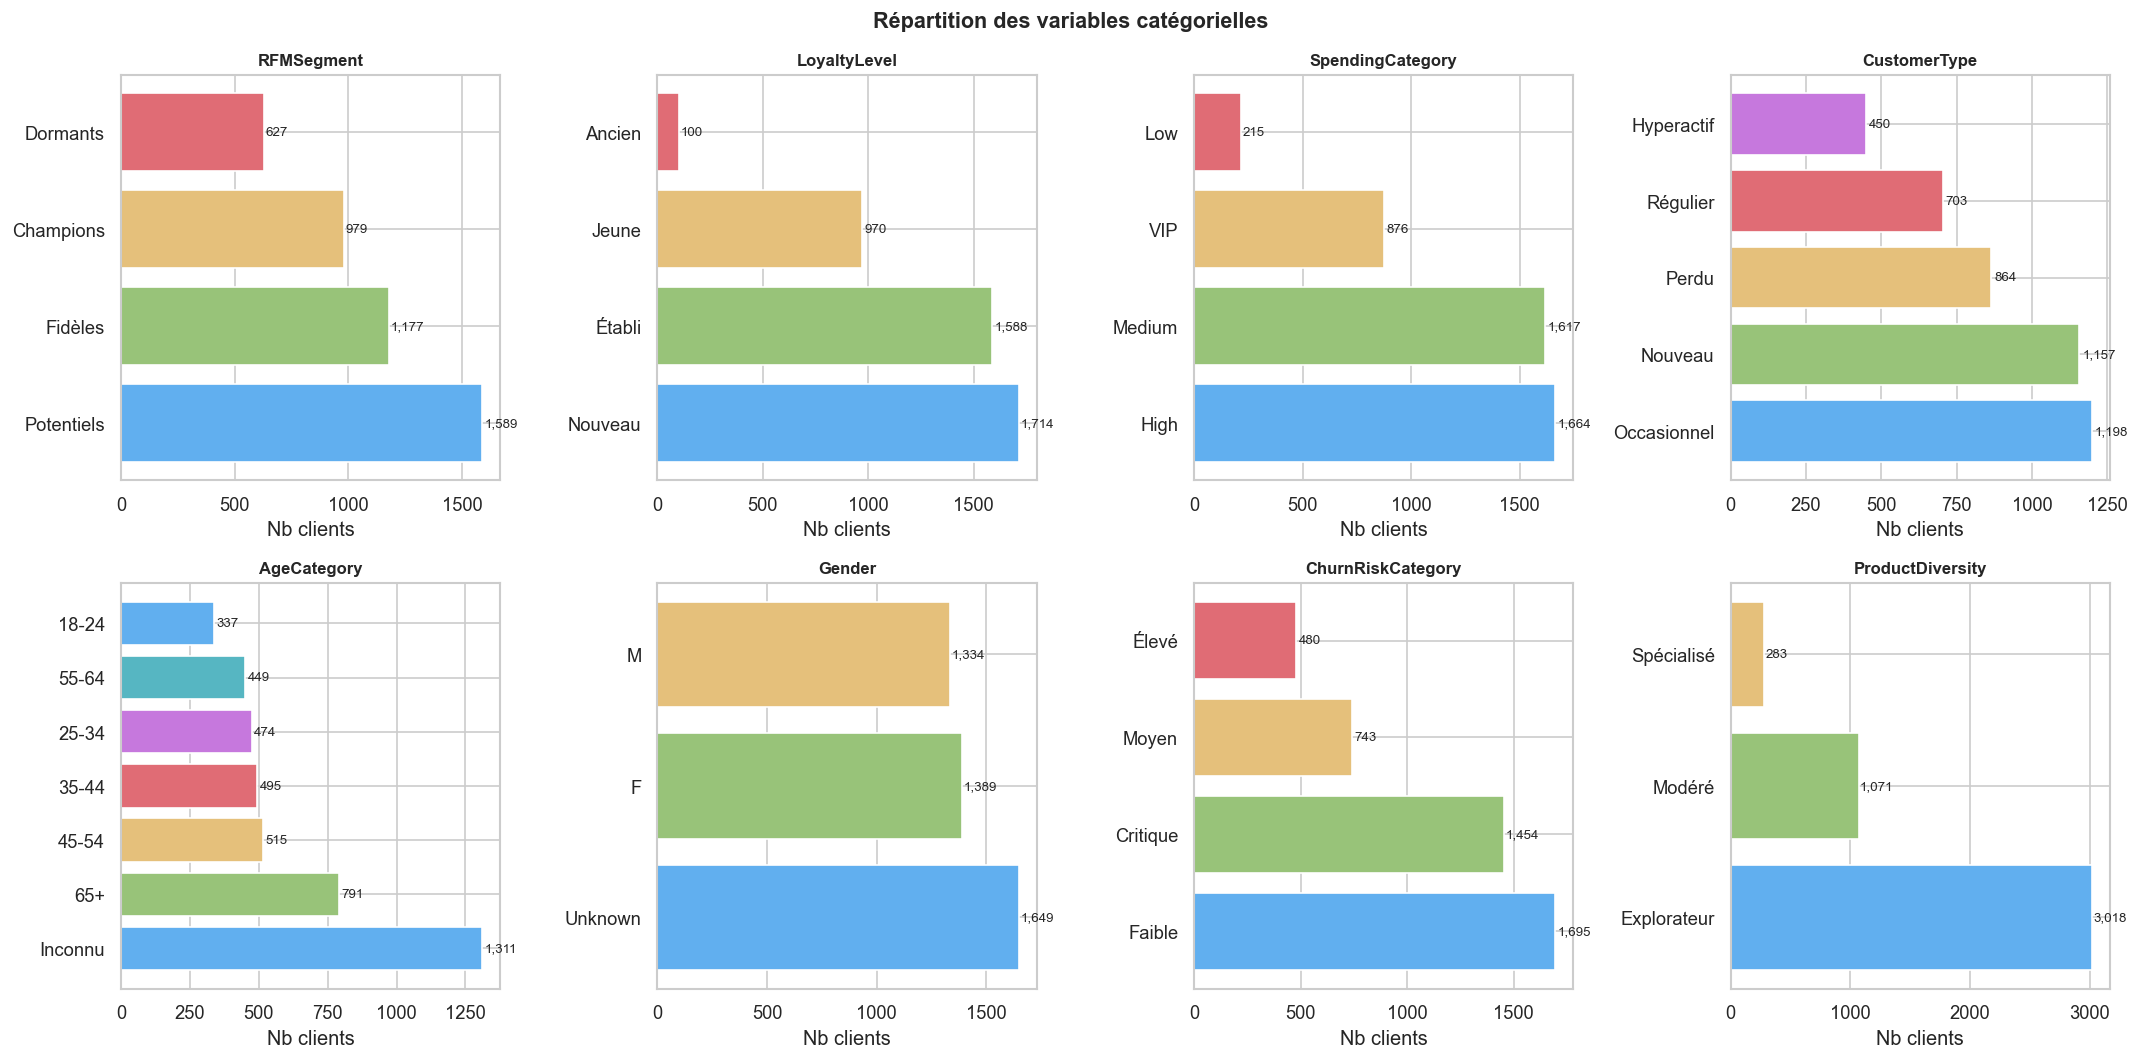

In [11]:
# Distribution des variables catégorielles clés
cat_key = ['RFMSegment', 'LoyaltyLevel', 'SpendingCategory', 'CustomerType',
           'AgeCategory', 'Gender', 'ChurnRiskCategory', 'ProductDiversity']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors_palette = ['#61afef', '#98c379', '#e5c07b', '#e06c75', '#c678dd', '#56b6c2']

for ax, col in zip(axes, cat_key):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values,
                   color=colors_palette[:len(counts)], edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Nb clients')
    for bar, val in zip(bars, counts.values):
        ax.text(val + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('Répartition des variables catégorielles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Résumé en pourcentages pour les segments clés
for col in ['RFMSegment', 'ChurnRiskCategory', 'SpendingCategory', 'LoyaltyLevel']:
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f'--- {col} ---')
    print(pct.to_string())
    print()

--- RFMSegment ---
RFMSegment
Potentiels   36.30
Fidèles      26.90
Champions    22.40
Dormants     14.30

--- ChurnRiskCategory ---
ChurnRiskCategory
Faible     38.80
Critique   33.30
Moyen      17.00
Élevé      11.00

--- SpendingCategory ---
SpendingCategory
High     38.10
Medium   37.00
VIP      20.00
Low       4.90

--- LoyaltyLevel ---
LoyaltyLevel
Nouveau   39.20
Établi    36.30
Jeune     22.20
Ancien     2.30



## 5. Analyse Bivariée — Relation avec le Churn

**Variable cible : `Churn`** (1 = client perdu, 0 = client actif)  
Taux de churn global : ~33%

📊 Taux de Churn global : 33.3%
   → Clients perdus  : 1,454
   → Clients actifs  : 2,918


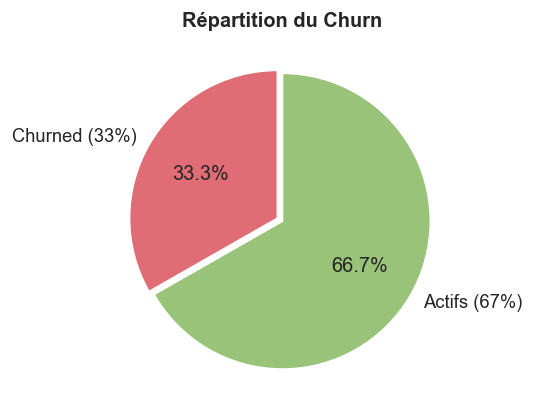

In [13]:
churn_rate = df['Churn'].mean() * 100
print(f'📊 Taux de Churn global : {churn_rate:.1f}%')
print(f'   → Clients perdus  : {df["Churn"].sum():,}')
print(f'   → Clients actifs  : {(df["Churn"]==0).sum():,}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie([df['Churn'].sum(), (df['Churn']==0).sum()],
       labels=['Churned (33%)', 'Actifs (67%)'],
       colors=['#e06c75', '#98c379'], autopct='%1.1f%%',
       startangle=90, explode=(0.04, 0))
ax.set_title('Répartition du Churn', fontweight='bold')
plt.show()

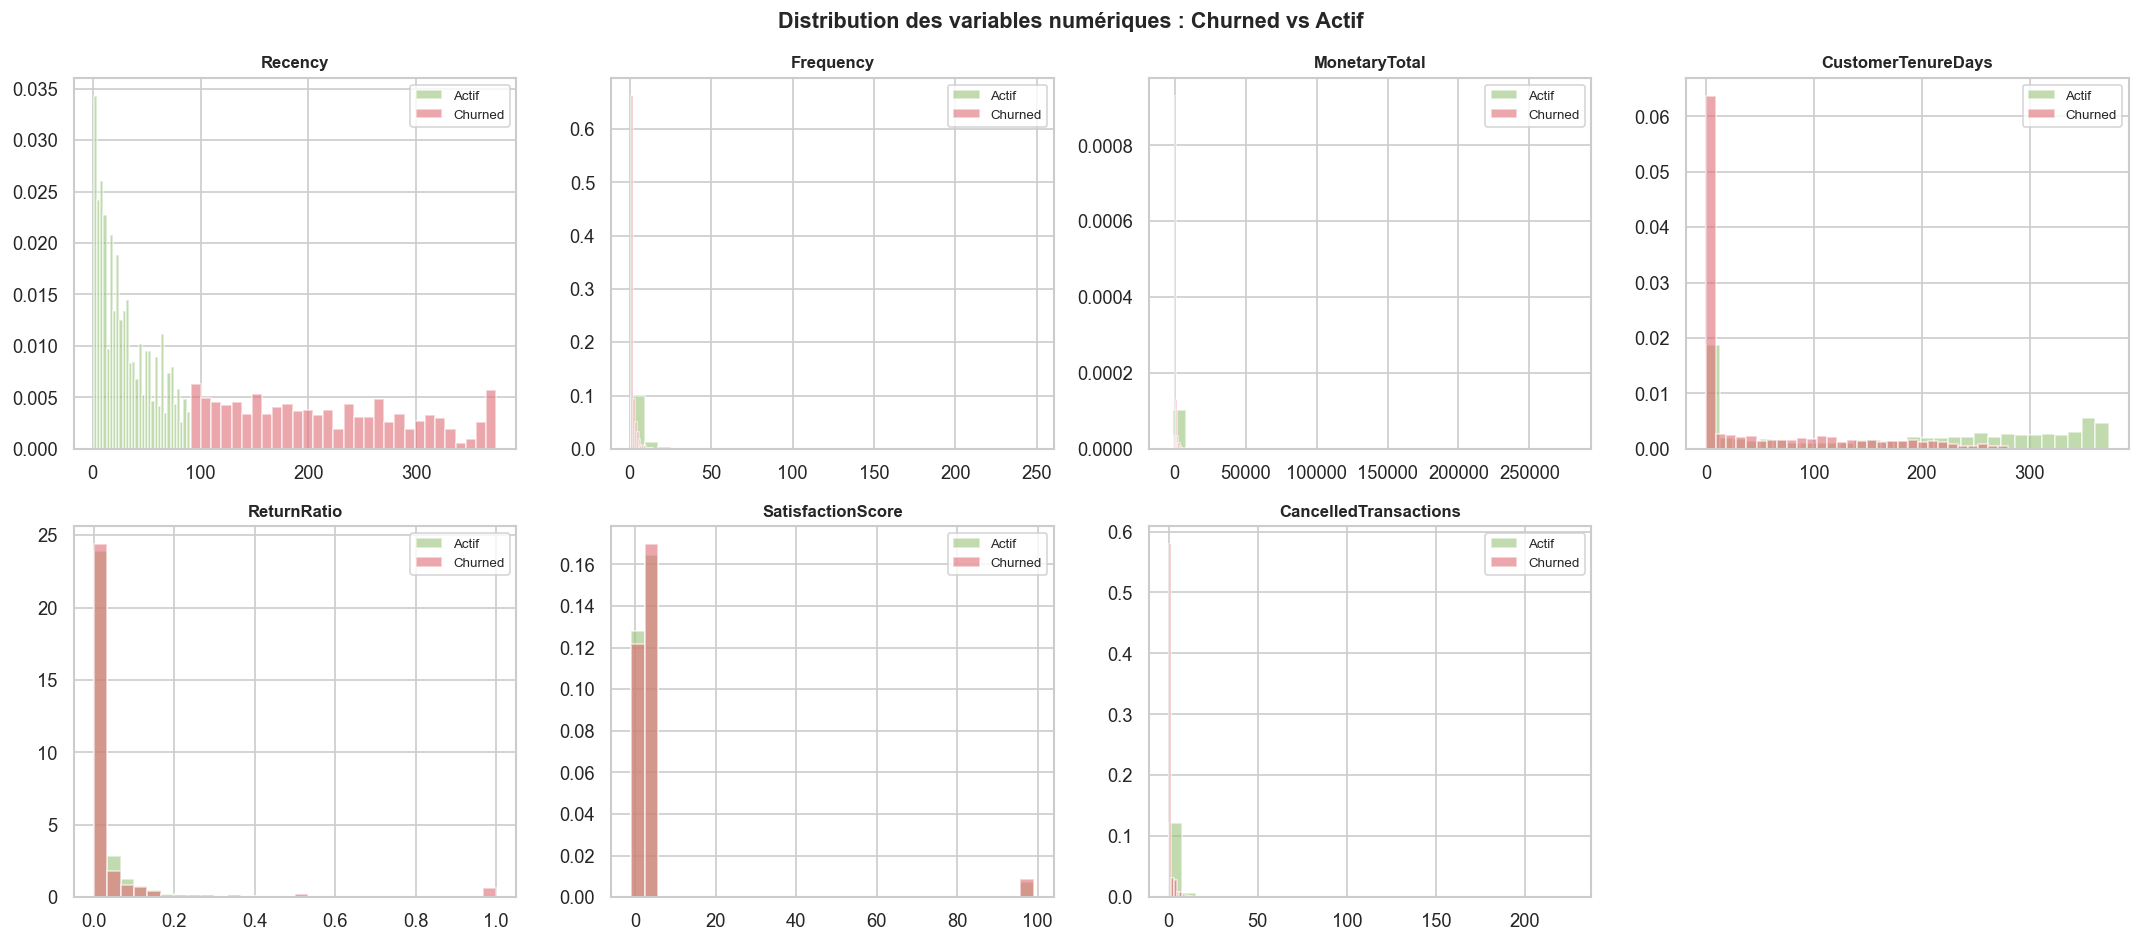

In [14]:
# Comparaison des variables numériques entre churners et non-churners
num_bivar = ['Recency', 'Frequency', 'MonetaryTotal', 'CustomerTenureDays',
             'ReturnRatio', 'SatisfactionScore', 'CancelledTransactions']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_bivar):
    for churn_val, color, label in zip([0, 1], ['#98c379', '#e06c75'], ['Actif', 'Churned']):
        data = df[df['Churn'] == churn_val][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution des variables numériques : Churned vs Actif', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

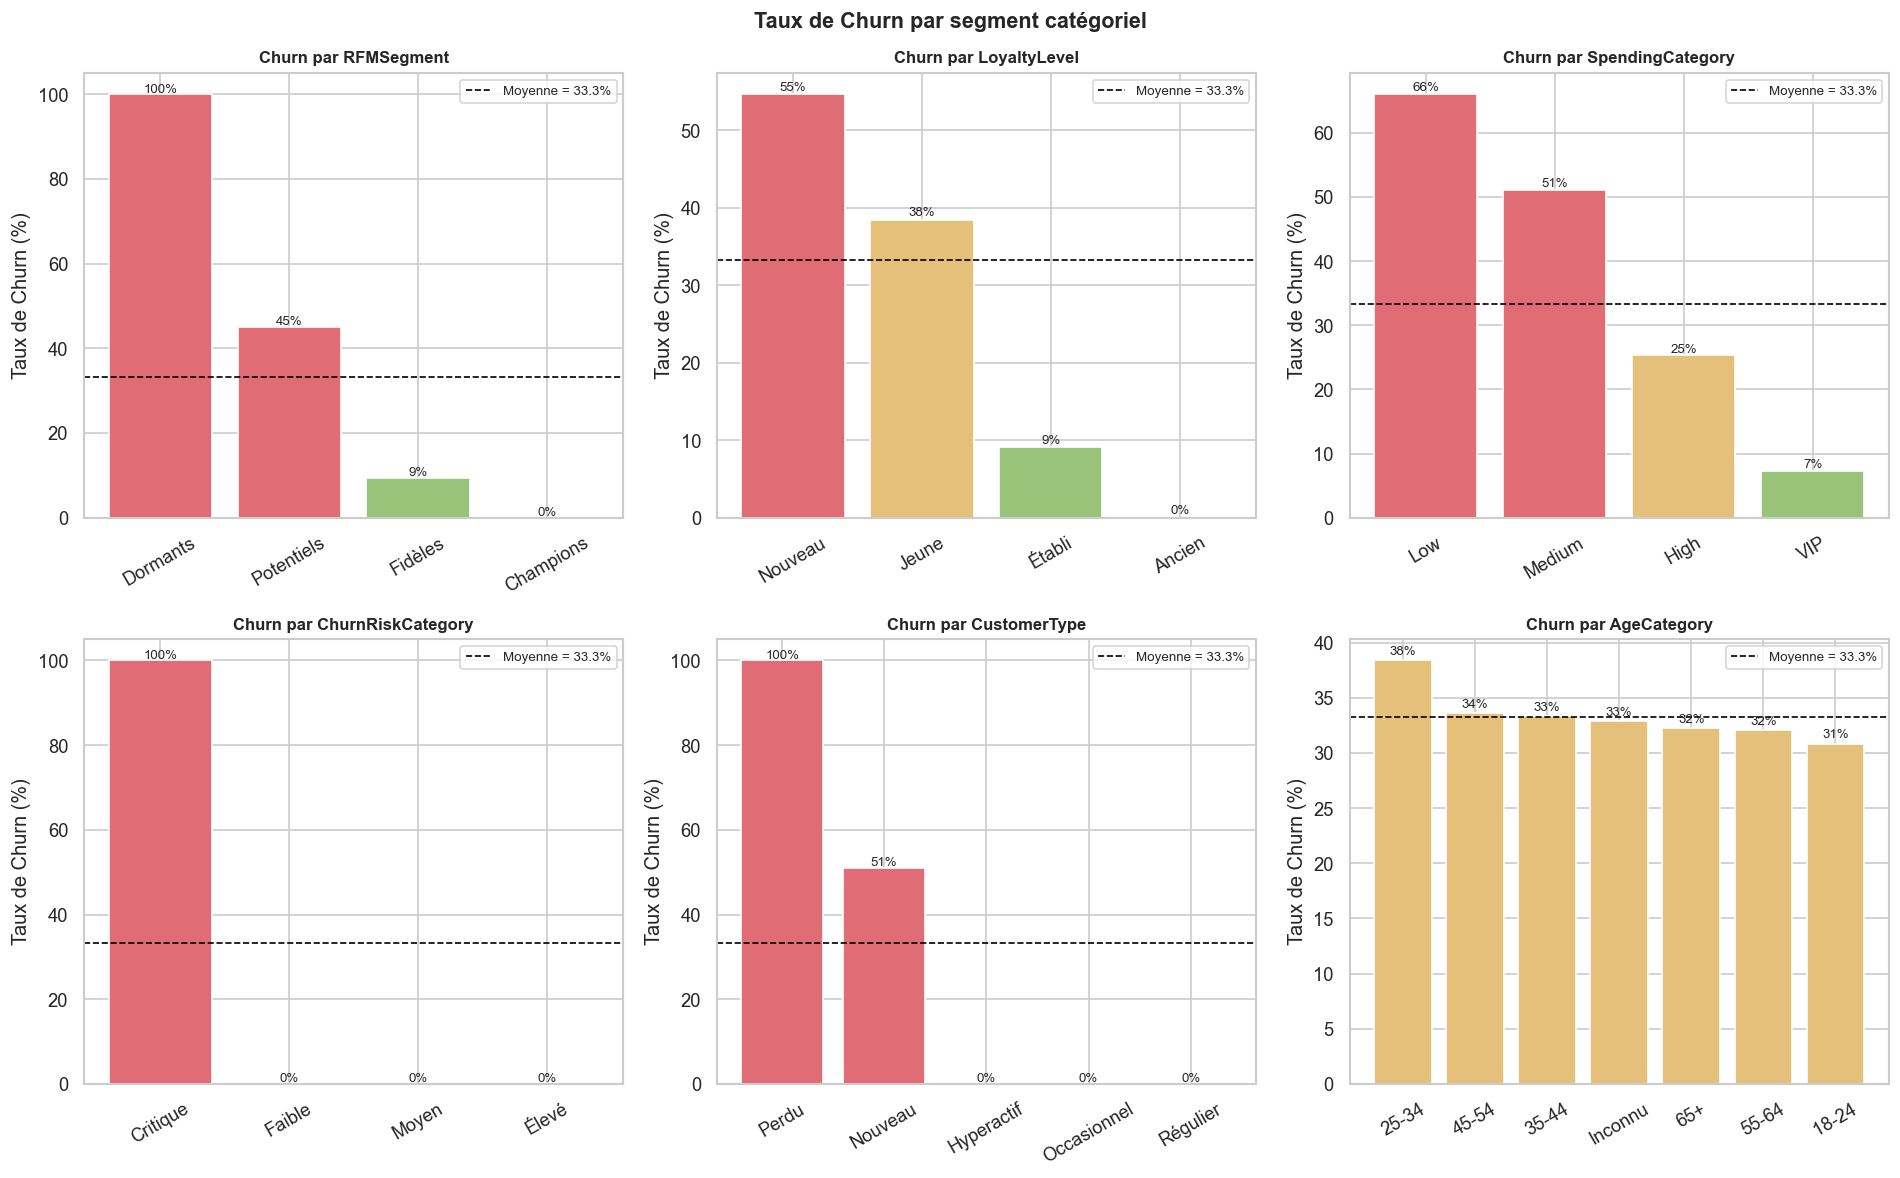

In [15]:
# Taux de churn par segment catégoriel
cat_churn_cols = ['RFMSegment', 'LoyaltyLevel', 'SpendingCategory',
                  'ChurnRiskCategory', 'CustomerType', 'AgeCategory']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_churn_cols):
    churn_by = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    colors = ['#e06c75' if v > 40 else '#e5c07b' if v > 25 else '#98c379'
              for v in churn_by.values]
    bars = ax.bar(churn_by.index, churn_by.values, color=colors, edgecolor='white')
    ax.axhline(churn_rate, color='black', linestyle='--', linewidth=1,
               label=f'Moyenne = {churn_rate:.1f}%')
    ax.set_title(f'Churn par {col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Taux de Churn (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_by.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f'{val:.0f}%', ha='center', fontsize=8)

plt.suptitle('Taux de Churn par segment catégoriel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Tableau statistique : moyennes par groupe Churn
churn_compare = df.groupby('Churn')[num_bivar].mean().T
churn_compare.columns = ['Actif (0)', 'Churned (1)']
churn_compare['Différence (%)'] = ((churn_compare['Churned (1)'] - churn_compare['Actif (0)'])
                                    / churn_compare['Actif (0)'] * 100).round(1)
display(churn_compare.round(2))

,Actif (0),Churned (1),Différence (%)
Recency,30.96,214.65,593.40
Frequency,6.54,2.13,-67.40
MonetaryTotal,2557.67,575.51,-77.50
CustomerTenureDays,175.90,48.06,-72.70
ReturnRatio,0.02,0.05,85.50
SatisfactionScore,5.18,5.63,8.60
CancelledTransactions,2.70,0.70,-74.30


## 6. Corrélations entre Variables Numériques

La heatmap permet d'identifier les redondances (multicolinéarité) et les variables les plus liées au churn.

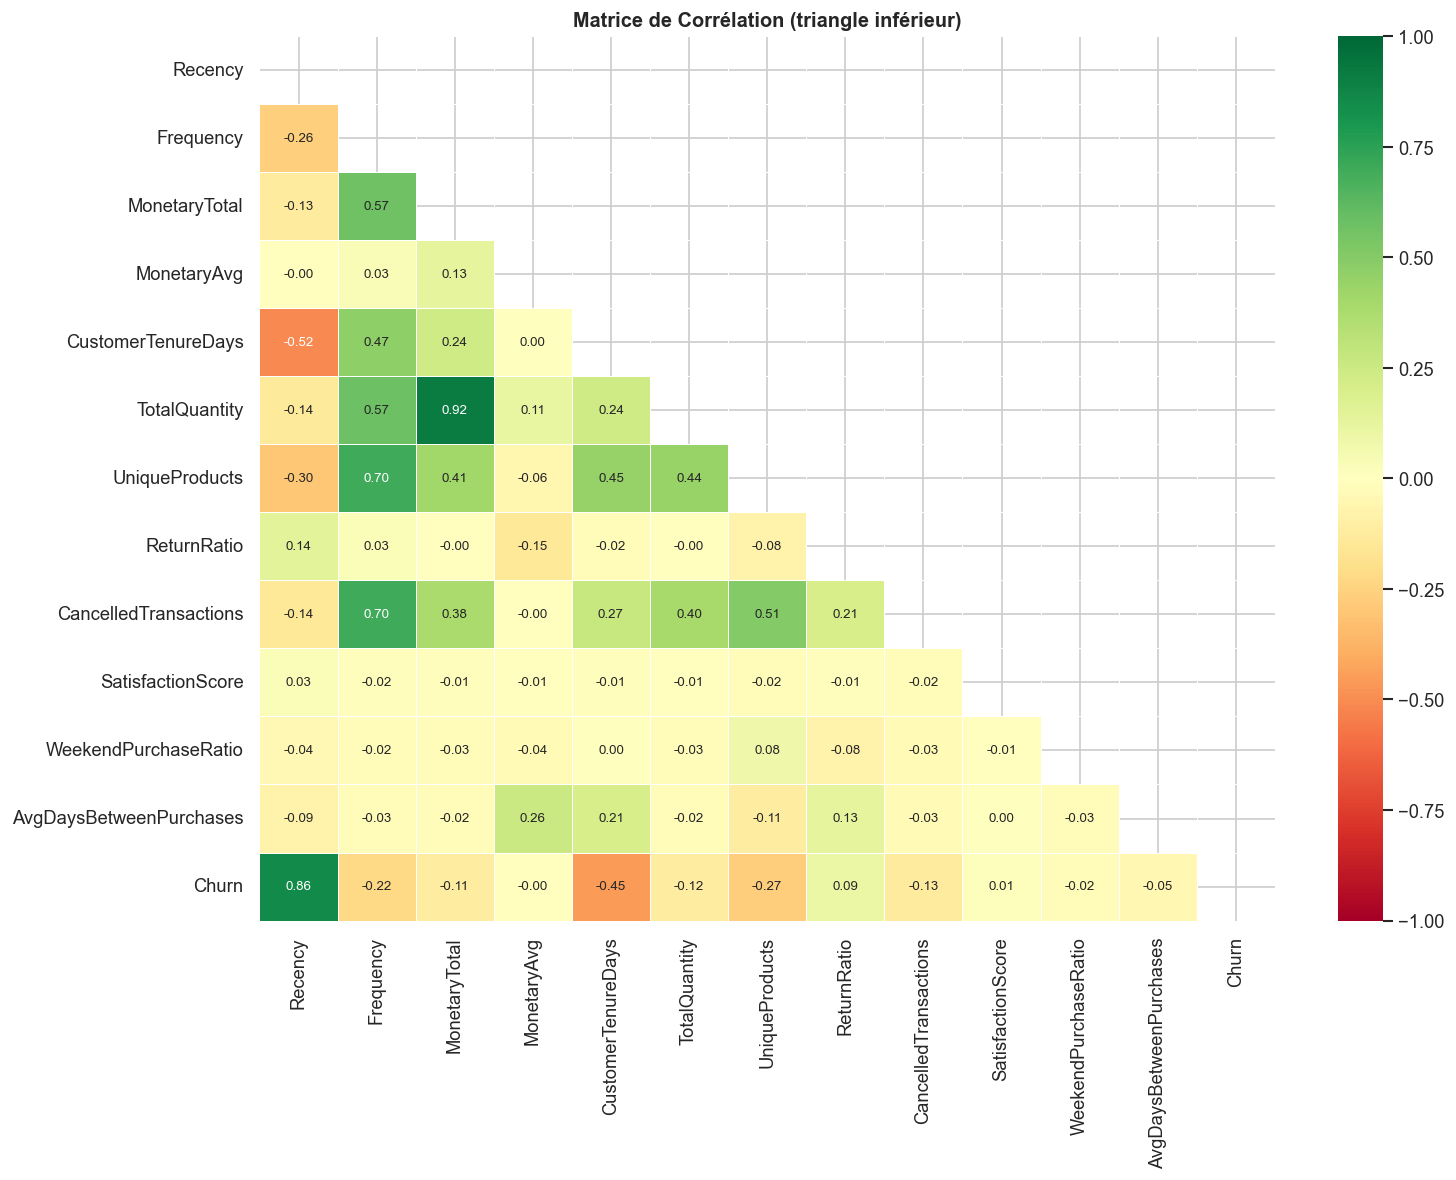


🎯 Corrélations avec la variable Churn :
Recency                    0.86
CustomerTenureDays        -0.45
UniqueProducts            -0.27
Frequency                 -0.22
CancelledTransactions     -0.13
TotalQuantity             -0.12
MonetaryTotal             -0.11
ReturnRatio                0.09
AvgDaysBetweenPurchases   -0.05
WeekendPurchaseRatio      -0.02
SatisfactionScore          0.01
MonetaryAvg               -0.00
Name: Churn, dtype: float64


In [17]:
# Matrice de corrélation (variables numériques clés)
corr_cols = ['Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
             'CustomerTenureDays', 'TotalQuantity', 'UniqueProducts',
             'ReturnRatio', 'CancelledTransactions', 'SatisfactionScore',
             'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'Churn']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Matrice de Corrélation (triangle inférieur)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Corrélations avec Churn triées
print('\n🎯 Corrélations avec la variable Churn :')
print(corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False).round(3))

## 7. Segmentation RFM & Profils Clients

In [18]:
# Profil moyen de chaque segment RFM
rfm_profile = df.groupby('RFMSegment').agg(
    Nb_clients=('CustomerID', 'count'),
    Recency_moy=('Recency', 'mean'),
    Frequency_moy=('Frequency', 'mean'),
    Monetary_moy=('MonetaryTotal', 'mean'),
    Churn_rate=('Churn', 'mean')
).round(1)
rfm_profile['Churn_rate'] = (rfm_profile['Churn_rate'] * 100).round(1)
rfm_profile = rfm_profile.sort_values('Monetary_moy', ascending=False)
display(rfm_profile)

,Nb_clients,Recency_moy,Frequency_moy,Monetary_moy,Churn_rate
RFMSegment,,,,,
Champions,979,13.70,13.80,5969.70,0.00
Fidèles,1177,44.10,4.10,1348.70,10.00
Potentiels,1589,117.20,1.90,491.80,50.00
Dormants,627,240.60,1.30,138.50,100.00


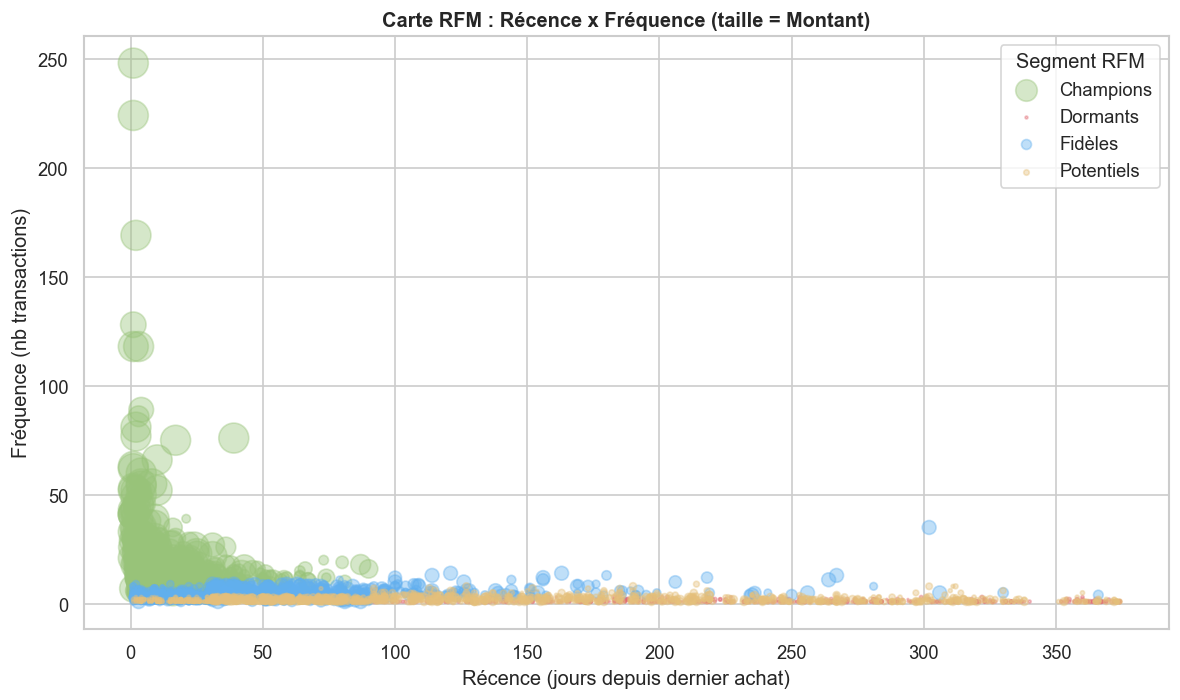

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_rfm = {'Champions': '#98c379', 'Fidèles': '#61afef',
              'Potentiels': '#e5c07b', 'Dormants': '#e06c75'}

for seg, grp in df.groupby('RFMSegment'):
    # Clamp à 0 pour éviter sqrt d'un négatif
    sizes = grp['MonetaryTotal'].clip(lower=0)
    sizes = sizes.clip(upper=sizes.quantile(0.95)) / 50

    ax.scatter(grp['Recency'], grp['Frequency'],
               s=sizes,
               alpha=0.4, color=colors_rfm.get(seg, 'gray'), label=seg)

ax.set_xlabel('Récence (jours depuis dernier achat)')
ax.set_ylabel('Fréquence (nb transactions)')
ax.set_title('Carte RFM : Récence x Fréquence (taille = Montant)', fontweight='bold')
ax.legend(title='Segment RFM')
plt.tight_layout()
plt.show()

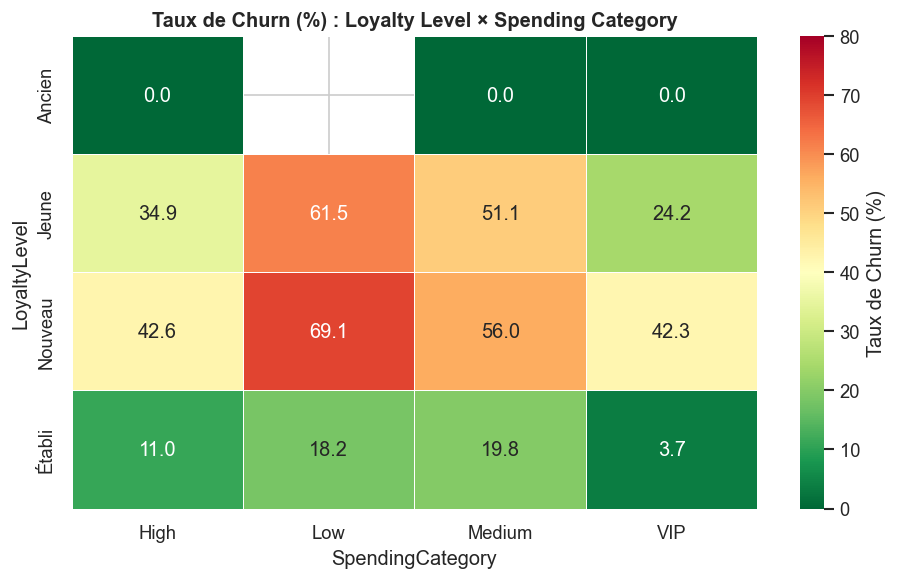

In [24]:
# Heatmap : Loyalty Level × Spending Category → Taux de Churn
loyalty_spend = df.pivot_table(values='Churn', index='LoyaltyLevel',
                                columns='SpendingCategory', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loyalty_spend, annot=True, fmt='.1f', cmap='RdYlGn_r',
            vmin=0, vmax=80, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Taux de Churn (%)'})
ax.set_title('Taux de Churn (%) : Loyalty Level × Spending Category', fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Profil complet par CustomerType
type_profile = df.groupby('CustomerType').agg(
    Nb=('CustomerID', 'count'),
    Recency_med=('Recency', 'median'),
    Frequency_med=('Frequency', 'median'),
    Monetary_med=('MonetaryTotal', 'median'),
    ReturnRatio_moy=('ReturnRatio', 'mean'),
    Churn_rate=('Churn', lambda x: f'{x.mean()*100:.0f}%')
).round(2)
display(type_profile)

,Nb,Recency_med,Frequency_med,Monetary_med,ReturnRatio_moy,Churn_rate
CustomerType,,,,,,
Hyperactif,450,7.50,15.00,4391.71,0.04,0%
Nouveau,1157,92.00,1.00,345.30,0.02,51%
Occasionnel,1198,32.00,3.00,691.14,0.03,0%
Perdu,864,264.50,1.00,275.52,0.06,100%
Régulier,703,19.00,6.00,1740.48,0.03,0%


## 8. Synthèse & Pistes de Modélisation

### 📋 Ce que l'on a découvert

| Dimension | Observation |
|-----------|-------------|
| **Taux de Churn** | 33% — déséquilibre modéré, à gérer avec SMOTE ou class_weight |
| **Recency** | Les churners ont une récence nettement plus élevée |
| **Frequency/Monetary** | Les Champions & Fidèles churent beaucoup moins |
| **Données manquantes** | Age (30%) → traité via la colonne AgeCategory ; AvgDaysBetweenPurchases (1.8%) |
| **NewsletterSubscribed** | Variance nulle (100% 'Yes') → **à supprimer** |
| **Géographie** | 90% UK → faible signal géographique pour un modèle global |
| **SatisfactionScore** | Valeurs aberrantes (−1, 99) à investiguer |

### 🚀 Recommandations pour la modélisation

1. **Feature engineering** : créer un score RFM pondéré, tenure en années, ratio cancelled/total
2. **Encodage** : LabelEncoder ou OrdinalEncoder pour les variables ordinales (LoyaltyLevel, SpendingCategory) ; One-Hot pour les nominales
3. **Modèles recommandés** : XGBoost ou LightGBM (robustes aux outliers), Logistic Regression (baseline)
4. **Métriques** : AUC-ROC + F1-Score (compte tenu du déséquilibre modéré)
5. **Variables à exclure** : CustomerID, LastLoginIP, RegistrationDate (brut), NewsletterSubscribed

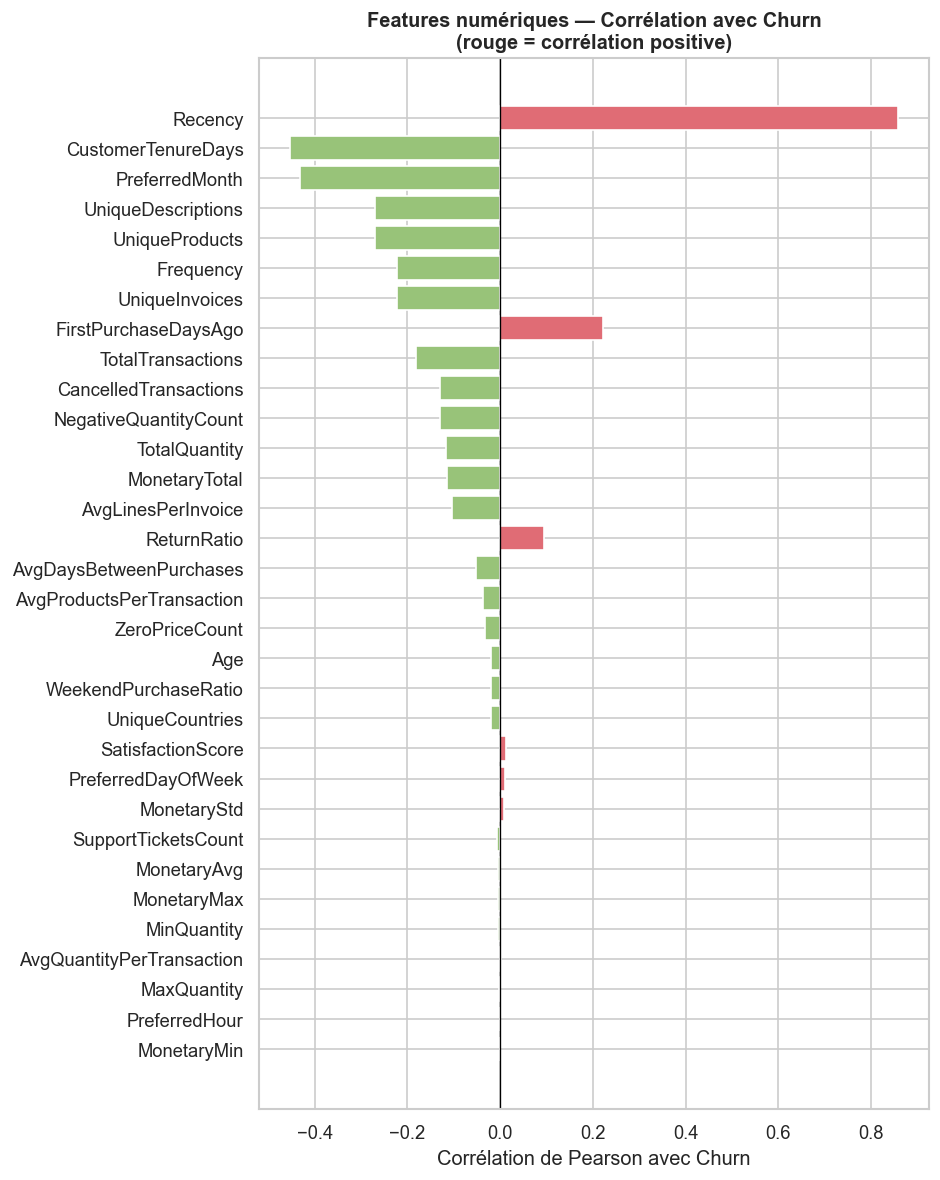

In [26]:
# Aperçu rapide : corrélations avec Churn (top features potentielles)
num_feats = [c for c in NUM_COLS if c not in ['CustomerID', 'Churn']]
churn_corr = df[num_feats + ['Churn']].corr()['Churn'].drop('Churn')
churn_corr = churn_corr.sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#e06c75' if v > 0 else '#98c379' for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation de Pearson avec Churn')
ax.set_title('Features numériques — Corrélation avec Churn\n(rouge = corrélation positive)', fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
df = pd.read_csv('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')

print("=== AccountStatus ===")
print(df['AccountStatus'].value_counts())
print(df['AccountStatus'].value_counts(normalize=True).mul(100).round(1))

=== AccountStatus ===
AccountStatus
Active       3944
Suspended     213
Pending       131
Closed         84
Name: count, dtype: int64
AccountStatus
Active      90.20
Suspended    4.90
Pending      3.00
Closed       1.90
Name: proportion, dtype: float64


In [29]:
import pandas as pd
import numpy as np

X_train = pd.read_csv('../data/train_test/X_train.csv')
y_train = pd.read_csv('../data/train_test/y_train.csv').squeeze()

# Correlation de chaque feature avec Churn
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations.head(20))

TenureRatio                   0.60
CustomerTenureDays            0.45
PreferredMonth                0.43
SpendingCategory              0.38
FavoriteSeason_Printemps      0.30
UniqueProducts                0.26
ProductDiversity_Modéré       0.24
Frequency                     0.22
WeekendPreference_Semaine     0.21
FavoriteSeason_Hiver          0.20
FavoriteSeason_Été            0.17
ProductDiversity_Spécialisé   0.16
CancelledTransactions         0.13
MonetaryTotal                 0.12
DaysSinceRegistration         0.12
Country_TargetEnc             0.11
ReturnRatio                   0.09
AvgBasketValue                0.07
AvgDaysBetweenPurchases       0.06
RegMonth                      0.06
dtype: float64


In [30]:
# Lance ça dans ton notebook pour voir les features exactes :
import joblib
model = joblib.load('../models/best_model.joblib')
scaler = joblib.load('../models/scaler.joblib')
print(scaler.feature_names_in_.tolist())
print(f"Nombre de features : {len(scaler.feature_names_in_)}")

['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'DaysSinceRegistration', 'RegMonth', 'AvgBasketValue', 'TenureRatio', 'ReturnToFrequencyRatio', 'IPFirstOctet', 'Country_TargetEnc']
Nombre de features : 23


In [31]:
import joblib
scaler = joblib.load('../models/scaler.joblib')
features = scaler.feature_names_in_.tolist()
print(f"Nombre total : {len(features)}")
print(features)

Nombre total : 23
['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'DaysSinceRegistration', 'RegMonth', 'AvgBasketValue', 'TenureRatio', 'ReturnToFrequencyRatio', 'IPFirstOctet', 'Country_TargetEnc']


In [32]:
import joblib
import pandas as pd

# Quel scaler est chargé ?
scaler = joblib.load('../models/scaler.joblib')
print(f"Features du scaler : {len(scaler.feature_names_in_)}")
print(scaler.feature_names_in_.tolist())

# Quel est le contenu de chaque fichier ?
df1 = pd.read_csv('../data/processed/retail_clean.csv')
df2 = pd.read_csv('../data/processed/retail_cleaned.csv')
print(f"\nretail_clean.csv    : {df1.shape}")
print(f"retail_cleaned.csv  : {df2.shape}")

Features du scaler : 23
['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'DaysSinceRegistration', 'RegMonth', 'AvgBasketValue', 'TenureRatio', 'ReturnToFrequencyRatio', 'IPFirstOctet', 'Country_TargetEnc']

retail_clean.csv    : (4372, 69)
retail_cleaned.csv  : (4372, 60)


In [34]:
import joblib

model = joblib.load('../models/best_model.joblib')
print(type(model))

# Voir les features attendues par le modèle directement
if hasattr(model, 'feature_names_in_'):
    print(f"Features du modèle : {len(model.feature_names_in_)}")
    print(model.feature_names_in_.tolist())
else:
    print(f"n_features_in_ : {model.n_features_in_}")

<class 'xgboost.sklearn.XGBClassifier'>
Features du modèle : 59
['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'DaysSinceRegistration', 'RegMonth', 'AvgBasketValue', 'TenureRatio', 'ReturnToFrequencyRatio', 'IPFirstOctet', 'Country_TargetEnc', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'AgeCategory', 'SpendingCategory', 'BasketSizeCategory', 'RegDay', 'RegWeekday', 'IsPrivateIP', 'FavoriteSeason_Hiver', 'FavoriteSeason_Printemps', 'FavoriteSeason_Été', 'PreferredTimeOfDay_Matin', 'PreferredTimeOfDay_Midi', 'PreferredTimeOfDay_Soir', 'Region_Amérique du Nord', 'Region_Amérique du Sud', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Eur

In [35]:
import joblib

scaler = joblib.load('../models/scaler.joblib')
model  = joblib.load('../models/best_model.joblib')

print(f"Scaler : {len(scaler.feature_names_in_)} features")
print(f"Modèle : {model.n_features_in_} features")
print("OK" if len(scaler.feature_names_in_) == model.n_features_in_ else "MISMATCH")

Scaler : 23 features
Modèle : 59 features
MISMATCH


In [36]:
import pandas as pd

df1 = pd.read_csv('../data/processed/retail_clean.csv')
df2 = pd.read_csv('../data/processed/retail_cleaned.csv')

# Lequel a 23 features numeriques (hors Churn) ?
print("retail_clean.csv colonnes :", df1.shape[1])
print(df1.columns.tolist())
print()
print("retail_cleaned.csv colonnes :", df2.shape[1])
print(df2.columns.tolist())

retail_clean.csv colonnes : 69
['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'LastLoginIP', 'SupportTicketsCount', 'SatisfactionScore', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country', 'Churn', 'CustomerTenure', 'MonetaryPerDay', 'AvgBasketValue', 'TenureRatio', 'Reg

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Charger le bon fichier
df = pd.read_csv('../data/processed/retail_cleaned.csv')

print(f"Shape : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")

# Vérifier que Churn est présent
print(f"\nChurn présent : {'Churn' in df.columns}")
print(df['Churn'].value_counts())

Shape : (4372, 60)
Colonnes : ['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'AgeCategory', 'SpendingCategory', 'BasketSizeCategory', 'Churn', 'TenureRatio', 'RegMonth', 'RegDay', 'RegWeekday', 'DaysSinceRegistration', 'IsPrivateIP', 'IPFirstOctet', 'AvgBasketValue', 'ReturnToFrequencyRatio', 'Country_TargetEnc', 'FavoriteSeason_Hiver', 'FavoriteSeason_Printemps', 'FavoriteSeason_Été', 'PreferredTimeOfDay_Matin', 'PreferredTimeOfDay_Midi', 'PreferredTimeOfDay_Soir', 'Region_Amérique du Nord', 'Region_Amérique du Sud', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord', 'Region_Eur

In [1]:
# Dans ton notebook, génère la liste pour app.py
import pandas as pd
df = pd.read_csv('../data/processed/retail_cleaned.csv')
features = [c for c in df.columns if c != 'Churn']
print(features)
print(f"Nombre : {len(features)}")

['Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryMax', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'UniqueCountries', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'AgeCategory', 'SpendingCategory', 'BasketSizeCategory', 'TenureRatio', 'RegMonth', 'RegDay', 'RegWeekday', 'DaysSinceRegistration', 'IsPrivateIP', 'IPFirstOctet', 'AvgBasketValue', 'ReturnToFrequencyRatio', 'Country_TargetEnc', 'FavoriteSeason_Hiver', 'FavoriteSeason_Printemps', 'FavoriteSeason_Été', 'PreferredTimeOfDay_Matin', 'PreferredTimeOfDay_Midi', 'PreferredTimeOfDay_Soir', 'Region_Amérique du Nord', 'Region_Amérique du Sud', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord', 'Region_Europe du Sud', 'Region_Moyen-Orient', 'Re